This notebook contains training ONLY the biophysical parameters of the single-compartment neuron model we are working with. We switched off the nerual network correction system here, so the results can play as a benchmark for our correction models.

In [1]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2


from jax import config
config.update("jax_enable_x64", True)



import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax
import jaxley as jx


import equinox as eqx
import flax.nnx as nnx

In [2]:
t_max = 80.0
cut = 1500

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"



# Define target
from voltage_fitting.build_simulator import (
    get_experimental_data,
)
t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


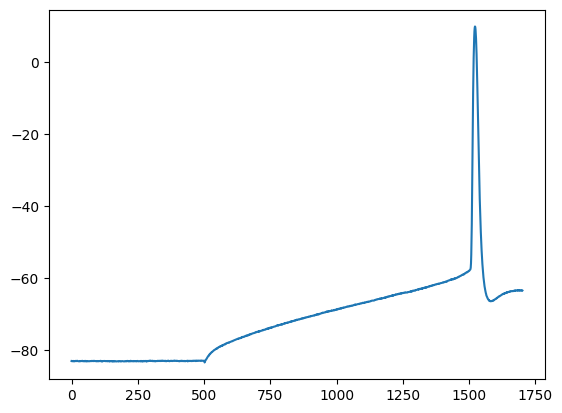

In [3]:
plt.plot(v_data[0])

In [4]:
#Define the cell
from voltage_fitting.single_build_simulator import (
    setup_simulator,
    setup_simulator_step,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)

from voltage_fitting.loss_util import (
    get_scaled_loss
)

seed = 0

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"])
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0])[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 15


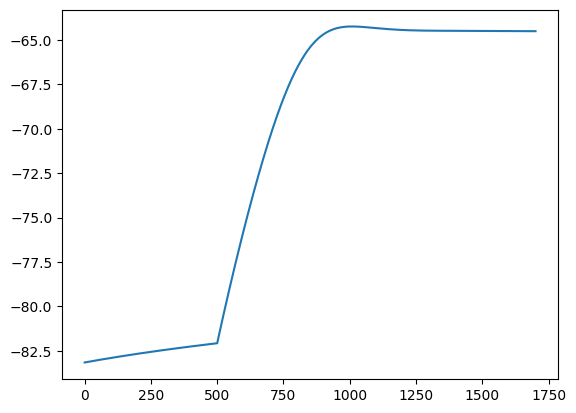

In [5]:
plt.plot(v_single[0])

In [6]:
# Normalizations
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_data)) / (jnp.max(v_data) - jnp.min(v_data)) - 1

@jax.jit
def softsign_transform(v):
    return v / (1 + jnp.abs(v))

@jax.jit
def tempered_tanh(v, scale=0.05):
    return jnp.tanh(scale * v)

In [7]:
class ParameterModel(eqx.Module):
    channel_params_normal: jax.Array

    def __init__(self, *, init_params):
        self.channel_params_normal = init_params

In [8]:
dt = 0.025
max_add_current = 1.0

def simulate_full_trace(initial_state, step_fn, current, time_vec, x_o, thr = None):
    def cond_fn(carry):
        t, _, _, diff = carry
        keep_running = t < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t, state, new_recs, diff = carry
        state, rec = step_fn(state, current[t])

        rec_voltage = rec[0]

        new_recs = new_recs.at[t].set(rec_voltage)

        new_diff = diff + (rec_voltage - x_o[t + 1])**2

        return (t + 1, state, new_recs, new_diff)

    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)

    carry = (0, initial_state, recs, 0.0)

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, recs, _ = final_carry

    return recs

In [9]:
cost_fn_power = 1.0
scale = 0.05 

def loss_fn(model, all_setup, t_max, i_amp, v_data, thr=300, dtw_reg = 1.0, spike_reg = 0.0, sse_reg = 0.0):

    params = inv_transform_params(model.channel_params_normal)

    # Rebuild the simulator with new cell
    initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = params)

    # Run simulation
    preds = simulate_full_trace(
        initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
    )

    preds = preds.squeeze()
    v_data = v_data.squeeze()

    sse_loss = jnp.sum(jnp.nan_to_num((preds - v_data) ** 2, nan=0.0))

    scaled_loss = get_scaled_loss(v_data, preds, cost_fn_power, scale)

    spike_loss = jnp.abs(jnp.max(preds) - jnp.max(v_data))
    
    return scaled_loss * dtw_reg + sse_loss * sse_reg + spike_loss * spike_reg

In [10]:
np.random.seed(42)
n_particles = 300

rngs = nnx.Rngs(1)
key = jax.random.PRNGKey(0)
keys = jax.random.split(jax.random.PRNGKey(0), num=n_particles)


all_setup = set_setup(setup)

thr = None


initial_lr = 15e-3 #2e-1 for lbfgs?
decay_factor = 0.99
transition_steps = 1  # decay after every epoch
#decay_until = 400 # after x epochs, stop decaying
decay_start = 1
decay_end = 350


opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_particles)
)


def initialize_model(init_params):
    model = ParameterModel(init_params=init_params)
    return model


models = jax.vmap(initialize_model)(opt_params)

raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)


def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr


adam_optimizer = optax.adam(learning_rate=custom_schedule)
lbfgs_optimizer = optax.chain(
            optax.scale_by_lbfgs(memory_size = 6), #8
            optax.scale(-1e-3), #0.3
        )
adamw_optimizer = optax.adamw(
    learning_rate=custom_schedule, 
    weight_decay=1e-4              
)

def init_adam_optimizer_state(model):
    return adam_optimizer.init(eqx.filter(model, eqx.is_inexact_array))

def init_lbfgs_optimizer_state(model):
    return lbfgs_optimizer.init(eqx.filter(model, eqx.is_inexact_array)) 

def init_adamw_optimizer_state(model):
    return adamw_optimizer.init(eqx.filter(model, eqx.is_inexact_array))


optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_lbfgs_optimizer_state)(models)

def simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, v_data, thr, dtw_reg = 1.0, spike_reg = 2.0, sse_reg = 0.0)
        return loss

def fine_simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, v_data, thr, dtw_reg = 0.0, spike_reg = 0.0, sse_reg = 1.0)
        return loss


grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(simulation_loss_fn)))
fine_grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(fine_simulation_loss_fn)))

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
# cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
# cell.soma.branch(0).comp(0).record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

In [11]:
def clip_channel_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    clipped = clip_leaf(grads.channel_params_normal)
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, clipped)
    return grads


def normalize_channel_gradients(grads, beta=1.0, eps=1e-8):
    norms = jnp.linalg.norm(grads.channel_params_normal, axis=1, keepdims=True)
    normalized = grads.channel_params_normal / (norms ** beta + eps)

    # Replace only the channel_params_normal field
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, normalized)
    return grads

def scale_grads(grads, lr_main, lr_channel):
    #grads_main_scaled = jax.tree_util.tree_map(lambda g: g * lr_main, grads)
    grads_channel_scaled = grads.channel_params_normal * lr_channel

    return eqx.tree_at(
        lambda g: g.channel_params_normal,
        #grads_main_scaled,
        grads_channel_scaled
    )

In [12]:
num_epochs = 300
mean_losses = []
best_losses = jnp.full((n_particles,), jnp.inf)
best_models = models  # Start with the initial models as best
grads_list = []

for epoch in range(num_epochs):

    # if epoch == 370: #370
    #     optimizer = optax.chain(
    #         optax.scale_by_lbfgs(memory_size = 8), #8
    #         optax.scale(-0.2e-1), #0.3
    #     )
    #     optimizer_state = nnx.Optimizer(optimizer_state.model, optimizer)
    

    loss, grads = grad_fn(models)
    grads_list.append(grads)
    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)



    improved = loss < best_losses
    best_losses = jnp.where(improved, loss, best_losses)

    def replace_if_improved(new, old):
        mask = improved.reshape((-1,) + (1,) * (new.ndim - 1))
        return jnp.where(mask, new, old)

    best_models = jax.tree_util.tree_map(replace_if_improved, models, best_models)

    mean_losses.append(jnp.mean(loss))

    updates, optimizer_states = jax.vmap(lambda g, s, m: adam_optimizer.update(g, s, m, step = epoch))(grads, optimizer_states, models)
    models = jax.vmap(eqx.apply_updates)(models, updates)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Mean Loss: {jnp.mean(loss):.6f}, Median Loss {jnp.median(loss):.6f}, Min Loss: {jnp.min(loss):.6f}")

        print('Max gradient norm: ', jnp.max(jnp.linalg.norm(grads.channel_params_normal, axis=1)), ', Min gradient norm: ', jnp.min(jnp.linalg.norm(grads.channel_params_normal, axis=1)))

/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Epoch 0, Mean Loss: 254.806250, Median Loss 242.586983, Min Loss: 146.900699
Max gradient norm:  9.999999999996827 , Min gradient norm:  6.232458105103001
Epoch 10, Mean Loss: 244.375216, Median Loss 234.081054, Min Loss: 155.190542
Max gradient norm:  9.99999999999975 , Min gradient norm:  7.1775566569138345
Epoch 20, Mean Loss: 233.998683, Median Loss 228.098754, Min Loss: 74.772393
Max gradient norm:  9.999999999996271 , Min gradient norm:  4.408111464692726
Epoch 30, Mean Loss: 224.062671, Median Loss 222.988388, Min Loss: 68.685121
Max gradient norm:  9.999999999998838 , Min gradient norm:  5.811735095258991
Epoch 40, Mean Loss: 218.972973, Median Loss 218.798546, Min Loss: 62.497188
Max gradient norm:  9.999999999998906 , Min gradient norm:  4.457562493362458
Epoch 50, Mean Loss: 211.885145, Median Loss 213.738264, Min Loss: 68.406059
Max gradient norm:  9.999999999997735 , Min gradient norm:  5.620464670309818
Epoch 60, Mean Loss: 205.281742, Median Loss 209.061223, Min Loss: 68

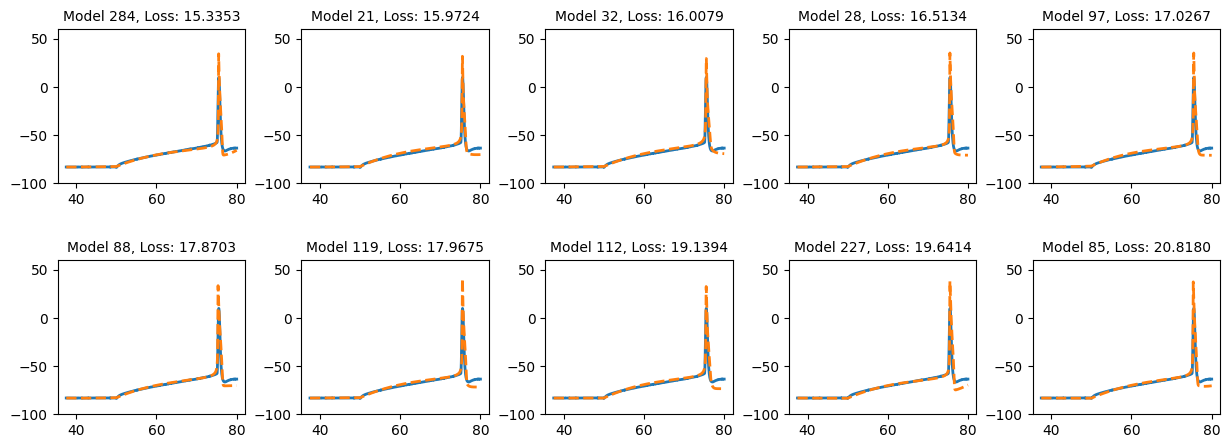

In [ ]:
#t = 80.0, epochs = 300, spike_reg=0.0
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

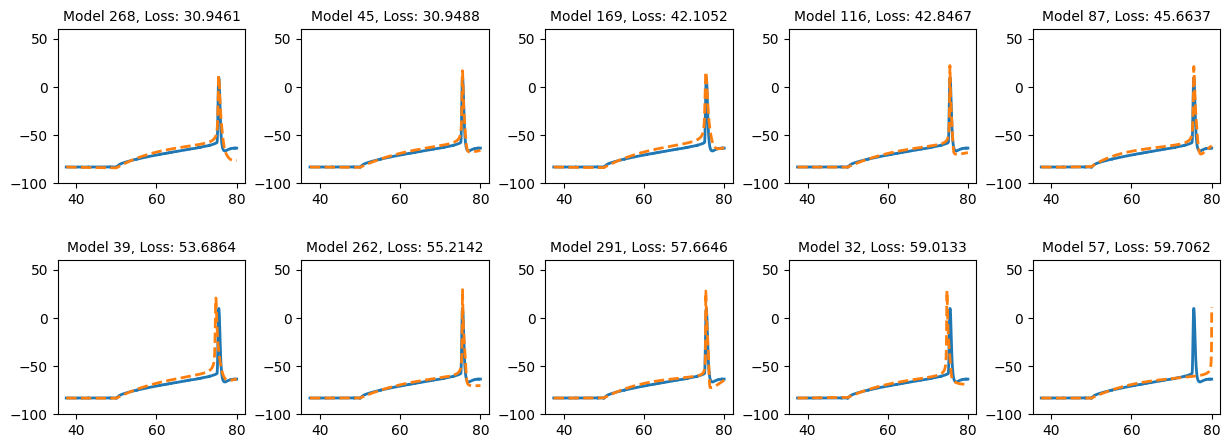

In [ ]:
#t = 80.0, epochs = 300, spike_reg=2.0
best_ten_preds = []
best_ten_losses = []
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        best_ten_preds.append(final_preds)
        best_ten_losses.append(best_losses[inds[i*5+j]])
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)
    
best_ten_preds = np.stack(best_ten_preds)
np.save("../results/best_preds_no_nn.npy", best_ten_preds)
np.save("../results/losses_no_nn.npy", best_ten_losses)
np.save("../results/v_data.npy", v_data)

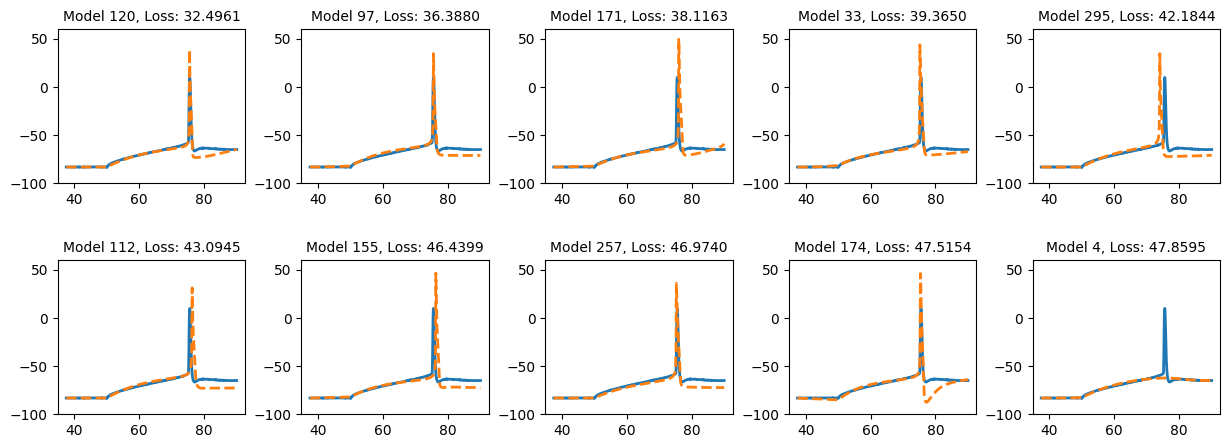

In [ ]:
#t = 90.0, epochs = 300, spike_reg=0.0
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

**Checking one prediction:**

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


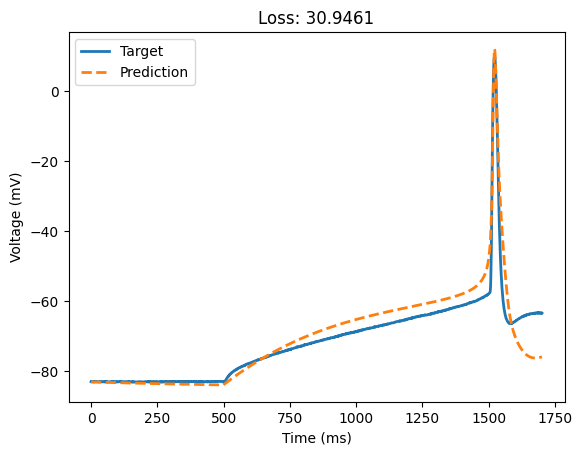

In [14]:
idx = 0
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current)
cell.record()
cell.set("v", all_setup['v_init'])
cell.init_states()

model = jax.tree_util.tree_map(lambda x: x[inds[idx]], best_models)
opt_inv_params = inv_transform_params(model.channel_params_normal)

# Rebuild the simulator with new cell
initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

# Run simulation
final_preds = simulate_full_trace(
    initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
)

loss = simulation_loss_fn(model)


plt.plot(v_data[0], label="Data target", linewidth=2)
plt.plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.title(f"Loss: {loss:.4f}")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend(["Target", "Prediction"])


**Fine-tuning the best 40 models with SSE loss**

In [16]:
top_k = 40
top_k_inds = inds[:top_k]
top_k_models = jax.tree_util.tree_map(lambda x: x[top_k_inds], best_models)
#top_k_losses = best_losses[top_k_inds]
top_k_losses = jnp.full((top_k,), jnp.inf)

fine_tune_lr = 5e-4  # 5e-5
decay_start = 100
decay_end = 200

fine_schedule = optax.exponential_decay(
    init_value=fine_tune_lr,
    transition_steps=1,
    decay_rate=1,
    staircase=True,
)
def fine_custom_schedule(step):
    # Epochs before decay_start → constant
    lr = fine_tune_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        fine_tune_lr,
        fine_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = fine_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

fine_optimizer = optax.adam(fine_custom_schedule)
# fine_optimizer = optax.sgd(learning_rate=1e-8, momentum=0.9)
# fine_optimizer = optax.chain(
#             optax.scale_by_lbfgs(memory_size = 8), #8
#             optax.scale(-1e-3), #0.3
#         )

fine_optimizer_states = jax.vmap(lambda m: fine_optimizer.init(eqx.filter(m, eqx.is_inexact_array)))(top_k_models)

num_fine_epochs = 300
fine_mean_losses = []
fine_best_models = top_k_models
fine_best_losses = top_k_losses

for epoch in range(num_fine_epochs):
    # if epoch == 0: #370
    #     fine_optimizer = optax.chain(
    #         optax.scale_by_lbfgs(memory_size = 6), #8
    #         optax.scale(-0.1e-1), #0.3
    #     )
    #     fine_optimizer_states = jax.vmap(lambda m: fine_optimizer.init(eqx.filter(m, eqx.is_inexact_array)))(top_k_models)

    loss, grads = fine_grad_fn(top_k_models)

    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)
    # grads = scale_grads(grads, lr_main=1e-4, lr_channel=10.0)

    improved = loss < fine_best_losses
    fine_best_losses = jnp.where(improved, loss, fine_best_losses)
    fine_best_models = jax.tree_util.tree_map(replace_if_improved, top_k_models, fine_best_models)

    updates, fine_optimizer_states = jax.vmap(lambda g, s, m: fine_optimizer.update(g, s, m, step=epoch))(grads, fine_optimizer_states, top_k_models)
    top_k_models = jax.vmap(eqx.apply_updates)(top_k_models, updates)

    fine_mean_losses.append(jnp.mean(loss))

    if epoch % 10 == 0:
        print(f"Fine-tune epoch {epoch}, Mean Loss: {jnp.mean(loss):.6f}, Median Loss {jnp.median(loss):.6f}, Min Loss: {jnp.min(loss):.6f}")
        # print('Max grad norm: ', jnp.max(jnp.linalg.norm(grads.channel_params_normal, axis=1)))


Fine-tune epoch 0, Mean Loss: 75250.734668, Median Loss 33741.294922, Min Loss: 9077.875000
Fine-tune epoch 10, Mean Loss: 40326.302344, Median Loss 22462.971680, Min Loss: 8631.866211
Fine-tune epoch 20, Mean Loss: 38205.884497, Median Loss 22299.276367, Min Loss: 8481.724609
Fine-tune epoch 30, Mean Loss: 35278.907910, Median Loss 20924.889648, Min Loss: 8478.723633
Fine-tune epoch 40, Mean Loss: 32184.937305, Median Loss 17921.505859, Min Loss: 8422.333008
Fine-tune epoch 50, Mean Loss: 36571.305811, Median Loss 16929.043945, Min Loss: 8344.650391
Fine-tune epoch 60, Mean Loss: 33106.407642, Median Loss 18355.044922, Min Loss: 8304.234375
Fine-tune epoch 70, Mean Loss: 37344.573120, Median Loss 16788.775391, Min Loss: 8273.171875
Fine-tune epoch 80, Mean Loss: 37423.395410, Median Loss 16745.212402, Min Loss: 8226.654297
Fine-tune epoch 90, Mean Loss: 38708.706250, Median Loss 18412.694336, Min Loss: 8185.568359
Fine-tune epoch 100, Mean Loss: 37449.029321, Median Loss 16685.571777,

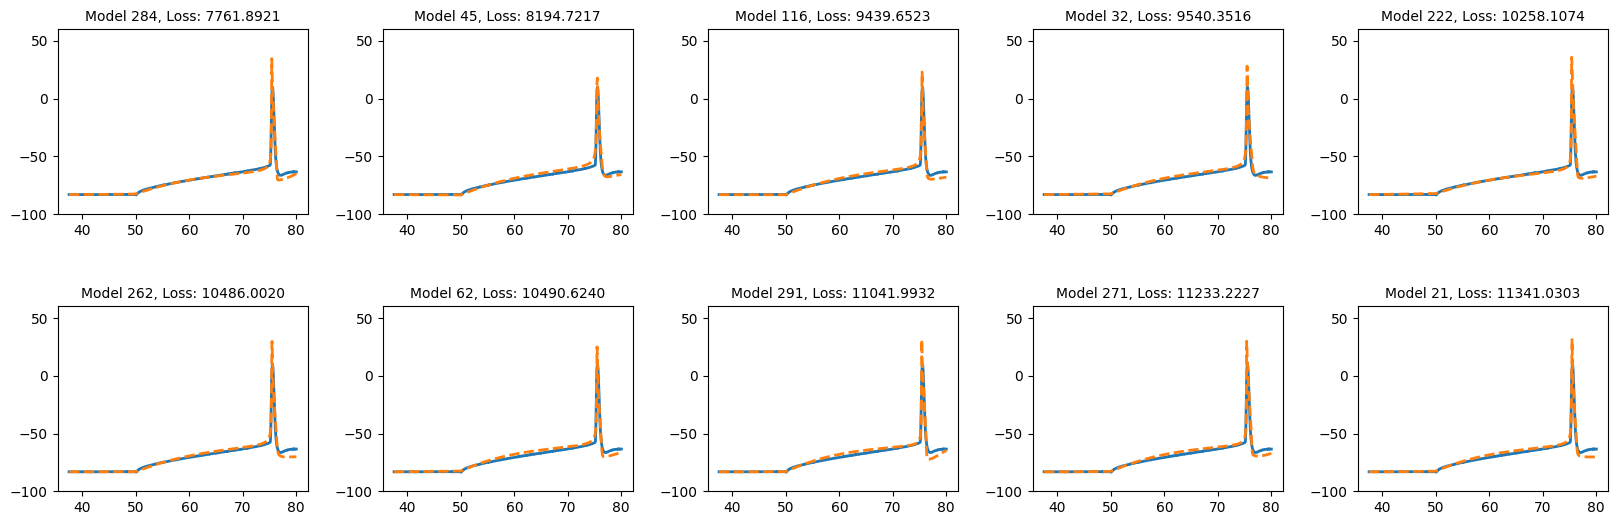

In [17]:
fine_inds = np.argsort(fine_best_losses)
fig, axs = plt.subplots(2,5, figsize = (20,6))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[fine_inds[i*5+j]], fine_best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[fine_inds[i*5+j]]}, Loss: {fine_best_losses[fine_inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


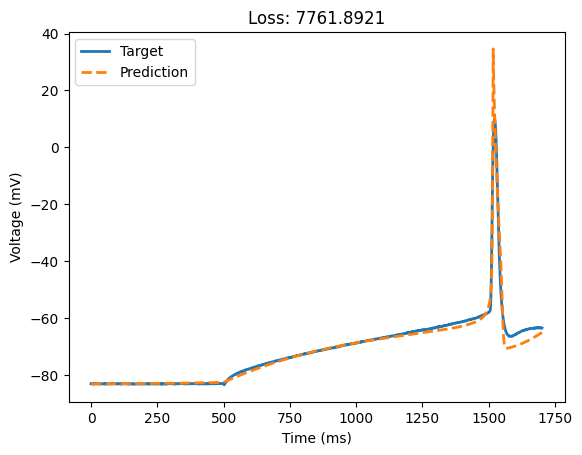

In [18]:
idx = 0

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
#cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current)
cell.record()
# cell.soma.branch(0).comp(0).stimulate(current)
# cell.soma.branch(0).comp(0).record()
cell.set("v", all_setup['v_init'])
cell.init_states()

model = jax.tree_util.tree_map(lambda x: x[fine_inds[idx]], fine_best_models)
opt_inv_params = inv_transform_params(model.channel_params_normal)

# Rebuild the simulator with new cell
initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

# Run simulation
final_preds = simulate_full_trace(
    initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
)

loss = fine_simulation_loss_fn(model)


plt.plot(v_data[0], label="Data target", linewidth=2)
plt.plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.title(f"Loss: {loss:.4f}")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend(["Target", "Prediction"])